In [1]:
import pandas as pd

In [66]:
v2_snw_copa_df = pd.read_csv('~/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv')

# Parse date column
v2_snw_copa_df['WAC_PRICE_COPA_DATE'] = pd.to_datetime(v2_snw_copa_df['WAC_PRICE_COPA_DATE'])

# Keep only items with at least 2 years of price history before 2024-01-01
cutoff_date = pd.Timestamp('2024-01-01')
min_history_date = cutoff_date - pd.DateOffset(years=2)  # 2022-01-01
items_with_history = (
    v2_snw_copa_df[v2_snw_copa_df['WAC_PRICE_COPA_DATE'] < cutoff_date]
    .groupby('COPA_MTRL_NUM')['WAC_PRICE_COPA_DATE']
    .min()
    .loc[lambda x: x <= min_history_date]
    .index
)
v2_snw_copa_df = v2_snw_copa_df[v2_snw_copa_df['COPA_MTRL_NUM'].isin(items_with_history)]

print(f'Items retained: {v2_snw_copa_df["COPA_MTRL_NUM"].nunique()}')
v2_snw_copa_df.columns

Items retained: 4309


Index(['COPA_FISCAL_YEAR_PERIOD', 'WAC_PRICE_COPA_DATE', 'COPA_MTRL_NUM',
       'COPA_NDC_NUM', 'COPA_WAC_PRICE', 'PREV_PERIOD_COPA_WAC_PRICE',
       'CUST_PROD_CATEGORY', 'SNW_NDC_NUM', 'SNW_MTRL_NUM',
       'SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT',
       'SNW_WAC_PRICE', 'SELL_DSCR', 'NET_REVENUE',
       'PREV_PERIOD_SNW_WAC_PRICE', 'COPA_SNW_WAC_PRICE_MATCH_IND',
       'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'IS_FUTURE_PERIOD_FLAG',
       'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING',
       'TOTAL_MONTHS_ROLLING', 'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE',
       'BASELINE_WAC_PRICE', 'PREV_PERIOD_BASELINE_WAC_PRICE',
       'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE',
       'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION'],
      dtype='str')

In [67]:
v2_snw_copa_df.groupby(['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'])
v2_snw_copa_df.head()

,COPA_FISCAL_YEAR_PERIOD,WAC_PRICE_COPA_DATE,COPA_MTRL_NUM,COPA_NDC_NUM,COPA_WAC_PRICE,PREV_PERIOD_COPA_WAC_PRICE,CUST_PROD_CATEGORY,SNW_NDC_NUM,SNW_MTRL_NUM,SNW_FIRST_EFF_DATE,...,SNW_NULL_MONTHS_ROLLING,TOTAL_MONTHS_ROLLING,PREFERRED_SOURCE,EFFECTIVE_SOURCE,BASELINE_WAC_PRICE,PREV_PERIOD_BASELINE_WAC_PRICE,MATERIAL_CUMULATIVE_REVENUE,TOTAL_CUMULATIVE_REVENUE,BASELINE_MOM_VAR_PCT,CUMULATIVE_REVENUE_PCT_CONTRIBUTION
0,2022010,2022-01-01,1101567,187301330.0,1052.31,NaN,BX,187301330.0,1101567.0,2022-01-01,...,0,1,COPA,COPA,1052.31,NaN,0.00,4.588214e+09,NaN,0.000000
1,2022011,2022-02-01,1101567,187301330.0,1053.33,1052.31,BX,187301330.0,1101567.0,2022-01-04,...,0,2,SNW,SNW,1053.33,1053.33,68129.83,6.999570e+09,0.0,0.000010
2,2022012,2022-03-01,1101567,187301330.0,1053.33,1053.33,BX,187301330.0,1101567.0,2022-01-04,...,0,3,SNW,SNW,1053.33,1053.33,117352.15,1.125410e+10,0.0,0.000010
3,2023001,2022-04-01,1101567,187301330.0,1053.33,1053.33,BX,187301330.0,1101567.0,2022-01-04,...,0,4,SNW,SNW,1053.33,1053.33,180525.24,1.365992e+10,0.0,0.000013
4,2023002,2022-05-01,1101567,187301330.0,1053.33,1053.33,BX,187301330.0,1101567.0,2022-01-04,...,0,5,SNW,SNW,1053.33,1053.33,221131.93,1.895925e+10,0.0,0.000012


In [68]:
v2_snw_copa_df = v2_snw_copa_df.sort_values(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE'])

In [69]:
change_now = (
    v2_snw_copa_df['BASELINE_WAC_PRICE'] != v2_snw_copa_df['PREV_PERIOD_BASELINE_WAC_PRICE']
).astype(int)

v2_snw_copa_df['TGT_CHANGE_UPCOMING_MNTH'] =(
    change_now
    .groupby(v2_snw_copa_df['COPA_MTRL_NUM'])
    .shift(-1)
    .fillna(0)
    .astype(int)
)

In [70]:
v2_snw_copa_df.columns

Index(['COPA_FISCAL_YEAR_PERIOD', 'WAC_PRICE_COPA_DATE', 'COPA_MTRL_NUM',
       'COPA_NDC_NUM', 'COPA_WAC_PRICE', 'PREV_PERIOD_COPA_WAC_PRICE',
       'CUST_PROD_CATEGORY', 'SNW_NDC_NUM', 'SNW_MTRL_NUM',
       'SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT',
       'SNW_WAC_PRICE', 'SELL_DSCR', 'NET_REVENUE',
       'PREV_PERIOD_SNW_WAC_PRICE', 'COPA_SNW_WAC_PRICE_MATCH_IND',
       'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'IS_FUTURE_PERIOD_FLAG',
       'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING',
       'TOTAL_MONTHS_ROLLING', 'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE',
       'BASELINE_WAC_PRICE', 'PREV_PERIOD_BASELINE_WAC_PRICE',
       'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE',
       'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
       'TGT_CHANGE_UPCOMING_MNTH'],
      dtype='str')

In [71]:
training_split = v2_snw_copa_df[v2_snw_copa_df['WAC_PRICE_COPA_DATE'] < '2024-01-01']
validation_split = v2_snw_copa_df[
    (v2_snw_copa_df['WAC_PRICE_COPA_DATE'] >= '2024-01-01') &
    (v2_snw_copa_df['WAC_PRICE_COPA_DATE'] < '2025-01-01')
]
test_split = v2_snw_copa_df[v2_snw_copa_df['WAC_PRICE_COPA_DATE'] >= '2025-01-01']
# Shuffle training set — preserve temporal order in test
training_split = training_split.sample(frac=1, random_state=42).reset_index(drop=True)

In [72]:
print(training_split.columns)


Index(['COPA_FISCAL_YEAR_PERIOD', 'WAC_PRICE_COPA_DATE', 'COPA_MTRL_NUM',
       'COPA_NDC_NUM', 'COPA_WAC_PRICE', 'PREV_PERIOD_COPA_WAC_PRICE',
       'CUST_PROD_CATEGORY', 'SNW_NDC_NUM', 'SNW_MTRL_NUM',
       'SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT',
       'SNW_WAC_PRICE', 'SELL_DSCR', 'NET_REVENUE',
       'PREV_PERIOD_SNW_WAC_PRICE', 'COPA_SNW_WAC_PRICE_MATCH_IND',
       'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'IS_FUTURE_PERIOD_FLAG',
       'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING',
       'TOTAL_MONTHS_ROLLING', 'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE',
       'BASELINE_WAC_PRICE', 'PREV_PERIOD_BASELINE_WAC_PRICE',
       'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE',
       'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
       'TGT_CHANGE_UPCOMING_MNTH'],
      dtype='str')


In [73]:
print(training_split.shape)
print(validation_split.shape)

(99897, 33)
(48515, 33)


In [76]:
cols_to_drop = [
    'TGT_CHANGE_UPCOMING_MNTH',         # target itself
    'BASELINE_WAC_PRICE',
    'WAC_PRICE_COPA_DATE',              # raw date — encoded separately
    'IS_FUTURE_PERIOD_FLAG',            # flags synthetic future rows, not real observations
    'COPA_NDC_NUM',                     # identifier, not a feature
    'COPA_MTRL_NUM',                    # identifier, not a feature
    'SNW_NDC_NUM',                      # identifier
    'SNW_MTRL_NUM',                     # identifier
    'SNW_LAST_EFF_DATE',                 # Leakage knowing that this date signals a price change
    'COPA_WAC_PRICE',
    'SNW_WAC_PRICE',
    'COPA_SNW_WAC_PRICE_MATCH_IND',
    'PREFERRED_SOURCE',
    'EFFECTIVE_SOURCE',
    'SELL_DSCR',
    'PREV_PERIOD_COPA_WAC_PRICE',
    'PREV_PERIOD_SNW_WAC_PRICE'
]
# NOTE: BASELINE_MOM_VAR_PCT and PREV_PERIOD_BASELINE_WAC_PRICE are kept —
# they reflect the *current* period trend, not future data.
y_train = v2_snw_copa_df['TGT_CHANGE_UPCOMING_MNTH']

In [77]:
X_train = v2_snw_copa_df.drop(cols_to_drop, axis=1)

In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['CUST_PROD_CATEGORY'] = le.fit_transform(X_train['CUST_PROD_CATEGORY'].astype(str))

# Store mapping for reference / inverse transform
prod_category_classes = list(le.classes_)
print(f"Encoded {len(prod_category_classes)} product categories: {prod_category_classes}")

Encoded 8 product categories: ['APOLLO', 'BIOSIMS', 'BX', 'DROP SHIP', 'GLP-1', 'MPB Plasma', 'MPB Specialty', 'VAX']


In [79]:
# Convert date columns to numeric (days since epoch)
date_cols = ['SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT']
for col in date_cols:
    if col in X_train.columns:
        X_train[col] = pd.to_datetime(X_train[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notna(x) else -1
        )

# Label-encode any remaining object columns
remaining_str_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f'Remaining string columns to encode: {remaining_str_cols}')
for col in remaining_str_cols:
    X_train[col] = LabelEncoder().fit_transform(X_train[col].astype(str))

print('All columns now numeric. dtypes:')
print(X_train.dtypes)

Remaining string columns to encode: []
All columns now numeric. dtypes:
COPA_FISCAL_YEAR_PERIOD                  int64
CUST_PROD_CATEGORY                       int64
SNW_FIRST_EFF_DATE                       int64
SNW_PRC_EFF_DT                           int64
NET_REVENUE                            float64
COPA_MOM_VAR_PCT                       float64
SNW_MOM_VAR_PCT                        float64
AVG_COPA_VARIANCE                      float64
AVG_SNW_VARIANCE                       float64
SNW_NULL_MONTHS_ROLLING                  int64
TOTAL_MONTHS_ROLLING                     int64
PREV_PERIOD_BASELINE_WAC_PRICE         float64
MATERIAL_CUMULATIVE_REVENUE            float64
TOTAL_CUMULATIVE_REVENUE               float64
BASELINE_MOM_VAR_PCT                   float64
CUMULATIVE_REVENUE_PCT_CONTRIBUTION    float64
dtype: object


In [80]:
X_train.columns

Index(['COPA_FISCAL_YEAR_PERIOD', 'CUST_PROD_CATEGORY', 'SNW_FIRST_EFF_DATE',
       'SNW_PRC_EFF_DT', 'NET_REVENUE', 'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT',
       'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING',
       'TOTAL_MONTHS_ROLLING', 'PREV_PERIOD_BASELINE_WAC_PRICE',
       'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE',
       'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION'],
      dtype='str')

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt',max_depth=8, class_weight='balanced',random_state=42)
rf_history = rf_model.fit(X_train, y_train)

              precision    recall  f1-score   support

   No Change       0.97      0.86      0.91     43781
Price Change       0.37      0.75      0.49      4734

    accuracy                           0.85     48515
   macro avg       0.67      0.81      0.70     48515
weighted avg       0.91      0.85      0.87     48515



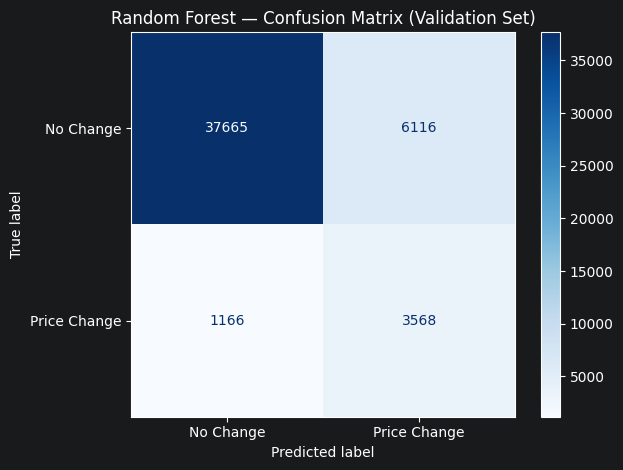

In [82]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Extract y_test before dropping columns
y_test = validation_split['TGT_CHANGE_UPCOMING_MNTH']

# Prepare test features — drop same cols as training, ignore any missing
X_test = validation_split.drop(cols_to_drop, axis=1, errors='ignore').copy()

# Apply same encodings as training
X_test['CUST_PROD_CATEGORY'] = le.transform(
    X_test['CUST_PROD_CATEGORY'].astype(str).map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
)
for col in ['SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT']:
    if col in X_test.columns:
        X_test[col] = pd.to_datetime(X_test[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notna(x) else -1
        )
for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = LabelEncoder().fit_transform(X_test[col].astype(str))

# Align columns to match training set exactly
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Predict and evaluate
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Change', 'Price Change']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Change', 'Price Change'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

In [83]:
# ── Regression: forecast next month WAC price ──────────────────────────
# Compute target on full df FIRST, then re-slice splits so they inherit it
v2_snw_copa_df["TGT_NEXT_MONTH_WAC"] = (
    v2_snw_copa_df.groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"]
    .shift(-1)
)

# Re-slice so splits have the new column
reg_train_full = v2_snw_copa_df[v2_snw_copa_df["WAC_PRICE_COPA_DATE"] < "2024-01-01"]
reg_test_full  = v2_snw_copa_df[
    (v2_snw_copa_df["WAC_PRICE_COPA_DATE"] >= "2024-01-01") &
    (v2_snw_copa_df["WAC_PRICE_COPA_DATE"] <  "2025-01-01")
]

reg_cols_to_drop = [
    "TGT_NEXT_MONTH_WAC",
    "TGT_CHANGE_UPCOMING_MNTH",
    "BASELINE_WAC_PRICE",
    "WAC_PRICE_COPA_DATE",
    "IS_FUTURE_PERIOD_FLAG",
    "COPA_NDC_NUM",
    "COPA_MTRL_NUM",
    "SNW_NDC_NUM",
    "SNW_MTRL_NUM",
    "SNW_LAST_EFF_DATE",
]

# Drop rows where target is unknown (last month per material has no next month)
reg_train = reg_train_full.dropna(subset=["TGT_NEXT_MONTH_WAC"]).copy()
reg_test  = reg_test_full.dropna(subset=["TGT_NEXT_MONTH_WAC"]).copy()

y_reg_train = reg_train["TGT_NEXT_MONTH_WAC"]
y_reg_test  = reg_test["TGT_NEXT_MONTH_WAC"]

X_reg_train = reg_train.drop(reg_cols_to_drop, axis=1, errors="ignore")
X_reg_test  = reg_test.drop(reg_cols_to_drop, axis=1, errors="ignore")
print(f"reg_train: {X_reg_train.shape}, reg_test: {X_reg_test.shape}")

reg_train: (99789, 24), reg_test: (48427, 24)


In [84]:
# Encode categoricals and dates — same pattern as classifier
le_reg = LabelEncoder()
X_reg_train["CUST_PROD_CATEGORY"] = le_reg.fit_transform(X_reg_train["CUST_PROD_CATEGORY"].astype(str))
X_reg_test["CUST_PROD_CATEGORY"]  = le_reg.transform(
    X_reg_test["CUST_PROD_CATEGORY"].astype(str).map(
        lambda x: x if x in le_reg.classes_ else le_reg.classes_[0]
    )
)

for col in ["SNW_FIRST_EFF_DATE", "SNW_PRC_EFF_DT"]:
    for df in [X_reg_train, X_reg_test]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").map(
                lambda x: x.toordinal() if pd.notna(x) else -1
            )

for col in X_reg_train.select_dtypes(include=["object"]).columns:
    enc = LabelEncoder()
    X_reg_train[col] = enc.fit_transform(X_reg_train[col].astype(str))
    X_reg_test[col]  = X_reg_test[col].astype(str).map(
        lambda x: enc.transform([x])[0] if x in enc.classes_ else 0
    )

X_reg_test = X_reg_test.reindex(columns=X_reg_train.columns, fill_value=0)

/var/folders/02/411qwrs54zv2qs02t9n6pzh40000gp/T/ipykernel_54850/2129905599.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_reg_train.select_dtypes(include=["object"]).columns:


In [85]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf_regressor.fit(X_reg_train, y_reg_train)
print("Regressor trained.")

Regressor trained.


Dollar WAPE : 0.0477  (4.77%)
Median |error| : $54.44
Mean   |error| : $120.76
Max    |error| : $12978.17


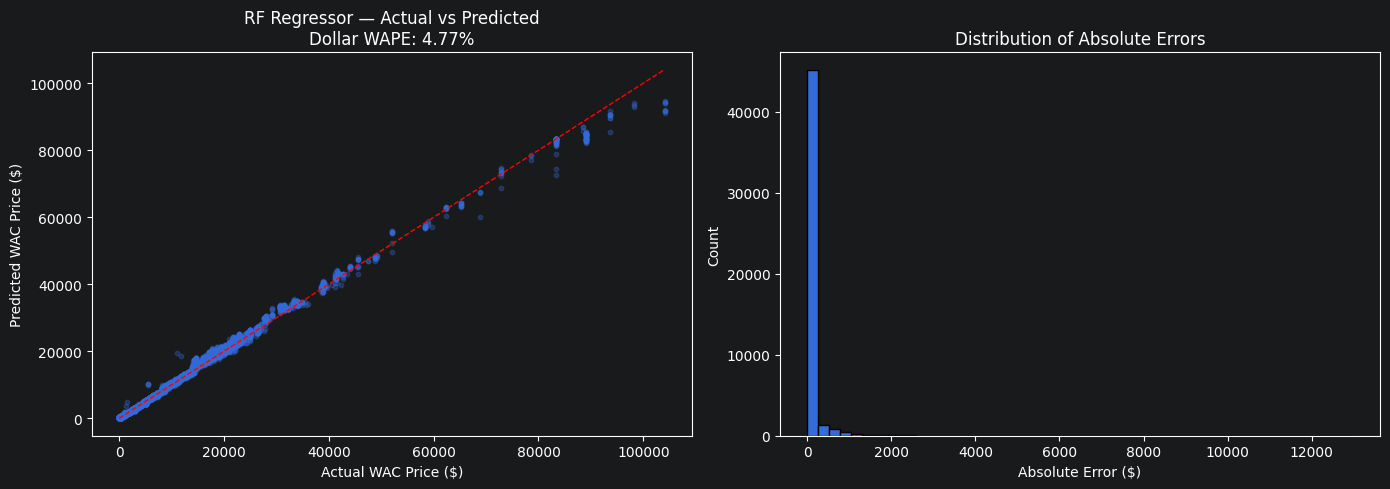

In [86]:
import numpy as np

y_reg_pred = rf_regressor.predict(X_reg_test)

# Dollar WAPE = SUM(|actual - predicted|) / SUM(actual)
dollar_wape = np.sum(np.abs(y_reg_test.values - y_reg_pred)) / np.sum(np.abs(y_reg_test.values))
print(f"Dollar WAPE : {dollar_wape:.4f}  ({dollar_wape*100:.2f}%)")

abs_errors = np.abs(y_reg_test.values - y_reg_pred)
print(f"Median |error| : ${np.median(abs_errors):.2f}")
print(f"Mean   |error| : ${np.mean(abs_errors):.2f}")
print(f"Max    |error| : ${np.max(abs_errors):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=10)
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], "r--", lw=1)
axes[0].set_xlabel("Actual WAC Price ($)")
axes[0].set_ylabel("Predicted WAC Price ($)")
axes[0].set_title(f"RF Regressor — Actual vs Predicted\nDollar WAPE: {dollar_wape*100:.2f}%")

axes[1].hist(abs_errors, bins=50, edgecolor="black")
axes[1].set_xlabel("Absolute Error ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Absolute Errors")

plt.tight_layout()
plt.show()